In [32]:
#0-1 EDAセッティング　基本設定

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

%matplotlib inline
%config Inlinebackend.figure_format='retina'
sns.set(style='whitegrid')
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns',100)

In [33]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
#0-2 パーケ読込
train=pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/Kaggle/IEEE-CIS Fraud Detection/加工後/train_merged.parquet')
test =pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/Kaggle/IEEE-CIS Fraud Detection/加工後/test_merged.parquet')

print(f"Memory Usage: {train.memory_usage().sum() / 1024**2:.2f} MB")
train.head()

Memory Usage: 645.97 MB


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,None,None,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,None,None,None,None,None,NaN,None,None,None,None,None,None,None,None
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,None,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,None,None,None,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,None,None,None,None,None,NaN,None,None,None,None,None,None,None,None
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,None,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,315.0,NaN,NaN,NaN,315.0,T,T,T,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,None,None,None,None,None,NaN,None,None,None,None,None,None,None,None
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,None,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,112.0,0.0,94.0,0.0,NaN,NaN,NaN,NaN,84.0,NaN,NaN,NaN,NaN,111.0,None,None,None,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,None,None,None,None,None,NaN,None,None,None,None,None,None,None,None
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN,gmail.com,None,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NotFound,NaN,-480.0,New,NotFound,166.0,NaN,542.0,144.0,NaN,NaN,None,NaN,NaN,NaN,None,New,NotFound,Android 7.0,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [35]:
#0-3 下処理前EDA　カラム説明　Kaggle引用

'''
【アイデンティティテーブル】
このテーブル内の変数は、取引に関連付けられた識別情報（ネットワーク接続情報
（IP、ISP、プロキシなど）とデジタル署名（UA/ブラウザ/OS/バージョンなど））
です。
これらは、Vestaの不正防止システムとデジタルセキュリティパートナーによって収
集されます。
（フィールド名はマスクされており、プライバシー保護と契約締結のため、ペアワイ
ズ辞書は提供されません。）

カテゴリ別特徴: DeviceType DeviceInfo id_12 - id_38

【取引表】
TransactionDT: 指定された参照日時からのタイムデルタ（実際のタイムスタンプで
　　　　　　　 はありません）
TransactionAMT: 取引支払金額（米ドル）
ProductCD: 製品コード、各トランザクションの製品
card1 - card6: カードの種類、カードのカテゴリ、発行銀行、国などの支払いカー
               ド情報。
addr: 住所
dist: 距離
P_ および (R__) emaildomain: 購入者と受信者のメールドメイン
C1-C14: 支払いカードに関連付けられているアドレスがいくつ見つかったかなどのカ
　　　　ウント。実際の意味はマスクされています。
D1-D15: 前回の取引間の日数などの時間差分。
M1-M9: カード名や住所などが一致します。
Vxxx: Vesta は、ランキング、カウント、その他のエンティティ関係を含む豊富な機
　　　能を設計しました。
カテゴリカル特徴: ProductCD card1 - card6 addr1, addr2 P_emaildomain
                  R_emaildomain M1 - M9

'''

'\n【アイデンティティテーブル】\nこのテーブル内の変数は、取引に関連付けられた識別情報（ネットワーク接続情報\n（IP、ISP、プロキシなど）とデジタル署名（UA/ブラウザ/OS/バージョンなど））\nです。\nこれらは、Vestaの不正防止システムとデジタルセキュリティパートナーによって収\n集されます。\n（フィールド名はマスクされており、プライバシー保護と契約締結のため、ペアワイ\nズ辞書は提供されません。）\n\nカテゴリ別特徴: DeviceType DeviceInfo id_12 - id_38\n\n【取引表】\nTransactionDT: 指定された参照日時からのタイムデルタ（実際のタイムスタンプで\n\u3000\u3000\u3000\u3000\u3000\u3000\u3000 はありません）\nTransactionAMT: 取引支払金額（米ドル）\nProductCD: 製品コード、各トランザクションの製品\ncard1 - card6: カードの種類、カードのカテゴリ、発行銀行、国などの支払いカー\n               ド情報。\naddr: 住所\ndist: 距離\nP_ および (R__) emaildomain: 購入者と受信者のメールドメイン\nC1-C14: 支払いカードに関連付けられているアドレスがいくつ見つかったかなどのカ\n\u3000\u3000\u3000\u3000ウント。実際の意味はマスクされています。\nD1-D15: 前回の取引間の日数などの時間差分。\nM1-M9: カード名や住所などが一致します。\nVxxx: Vesta は、ランキング、カウント、その他のエンティティ関係を含む豊富な機\n\u3000\u3000\u3000能を設計しました。\nカテゴリカル特徴: ProductCD card1 - card6 addr1, addr2 P_emaildomain\n                  R_emaildomain M1 - M9\n\n'

In [36]:
'''
後続処理
①下処理前EDA
　なお、長くなったため、見出しに特徴量等を変化させたものは(活用)、
　変化はないが有効な情報に(参考)を付与した。
②欠損処理の検討
③特徴量変換(ビン分け、外れ値処理、ラベル化の検討)
④下処理後EDA
'''

'\n後続処理\n①下処理前EDA\n\u3000なお、長くなったため、見出しに特徴量等を変化させたものは(活用)、\n\u3000変化はないが有効な情報に(参考)を付与した。\n②欠損処理の検討\n③特徴量変換(ビン分け、外れ値処理、ラベル化の検討)\n④下処理後EDA\n'

In [37]:
#1-1 下処理前EDA 欠損再確認(マージ後)

null_counts   = train.isnull().sum()
null_columns  = null_counts[null_counts > 0]
mis_ratio     = len(null_columns)/len(train.columns)*100
clean_columns = null_counts[null_counts == 0].index.tolist()
total_cols    = len(train.columns)

#無欠損カラム
print(f"===========無欠損カラム一覧 (計 {len(clean_columns)}件) ============")
if len(clean_columns) > 0:
  for i in range(0, len(clean_columns), 5):
    print(", ".join(clean_columns[i:i+5]))
else:
  print("無欠損なし")
print("\n" + "="*50 + "\n")

#欠損カラム
if null_columns.empty:
  print('欠損値なし')
else:
  print(f'欠損あり(全{total_cols}カラム中) {len(null_columns)}件】 ({mis_ratio:.2f}%)')
  tmp_df=null_columns.to_frame(name='ncounts')
  tmp_df['ratio']=(tmp_df['ncounts'] / len(train)) * 100
  df_ratio_desc=tmp_df.sort_values('ratio',ascending=False)

  for ncol,row in df_ratio_desc.iterrows():
    count = row['ncounts']
    ratio = row['ratio']
    print(f'カラム名: {ncol:<15} | 欠損数: {int(count):>8} / 全レコード数: {len(train)} | 割合: {ratio:>6.2f}%')

===========無欠損カラム一覧 (計 20件) ============
TransactionID, isFraud, TransactionDT, TransactionAmt, ProductCD
card1, C1, C2, C3, C4
C5, C6, C7, C8, C9
C10, C11, C12, C13, C14


欠損あり(全434カラム中) 414件】 (95.39%)
カラム名: id_24           | 欠損数:   585793 / 全レコード数: 590540 | 割合:  99.20%
カラム名: id_25           | 欠損数:   585408 / 全レコード数: 590540 | 割合:  99.13%
カラム名: id_07           | 欠損数:   585385 / 全レコード数: 590540 | 割合:  99.13%
カラム名: id_08           | 欠損数:   585385 / 全レコード数: 590540 | 割合:  99.13%
カラム名: id_21           | 欠損数:   585381 / 全レコード数: 590540 | 割合:  99.13%
カラム名: id_26           | 欠損数:   585377 / 全レコード数: 590540 | 割合:  99.13%
カラム名: id_23           | 欠損数:   585371 / 全レコード数: 590540 | 割合:  99.12%
カラム名: id_22           | 欠損数:   585371 / 全レコード数: 590540 | 割合:  99.12%
カラム名: id_27           | 欠損数:   585371 / 全レコード数: 590540 | 割合:  99.12%
カラム名: dist2           | 欠損数:   552913 / 全レコード数: 590540 | 割合:  93.63%
カラム名: D7              | 欠損数:   551623 / 全レコード数: 590540 | 割合:  93.41%
カラム名: id_18           | 欠損数:   545427 

95％超のカラムが欠損あり。  
全てにおいて欠損補完と特徴量変換を行うのは現実的ではないため、軽度にEDA実施後、モデル寄与度を確認し、不要なカラムを削除。

In [38]:
#1-2 (参考)下処理前EDA　均衡確認(不正件数、正常件数、、全体件数、不正割合)　アップキャスト

# 1. 計算用に型を float64 にキャスト（オーバーフロー対策）
safe_amt = train['TransactionAmt'].astype('float64')

# 2. 件数と割合の算出
total_count = len(train)
fraud_counts = train['isFraud'].value_counts()
fraud_rates = train['isFraud'].value_counts(normalize=True) * 100

# 3. 金額ベースの集計
fraud_amt_sum = safe_amt[train['isFraud'] == 1].sum()
normal_amt_sum = safe_amt[train['isFraud'] == 0].sum()
total_amt_sum = fraud_amt_sum + normal_amt_sum
fraud_amt_rate = (fraud_amt_sum / total_amt_sum) * 100

# 4. まとめテーブルの作成
eda_summary = pd.DataFrame({
    '項目': ['正常 (0)', '不正 (1)', '全体'],
    '件数': [f"{fraud_counts[0]:,}", f"{fraud_counts[1]:,}", f"{total_count:,}"],
    '件数割合 (%)': [f"{fraud_rates[0]:.2f}%", f"{fraud_rates[1]:.2f}%", "100.00%"],
    '総金額': [f"{normal_amt_sum:,.0f}", f"{fraud_amt_sum:,.0f}", f"{total_amt_sum:,.0f}"],
    '金額割合 (%)': [f"{(100 - fraud_amt_rate):.2f}%", f"{fraud_amt_rate:.2f}%", "100.00%"]
})

print("--- isFraud の分布：件数と金額の比較 ---")
display(eda_summary)

--- isFraud の分布：件数と金額の比較 ---


,項目,件数,件数割合 (%),総金額,金額割合 (%)
0,正常 (0),"569,877",96.50%,"76,655,214",96.13%
1,不正 (1),"20,663",3.50%,"3,083,836",3.87%
2,全体,"590,540",100.00%,"79,739,050",100.00%


不正件数割合3.5％　不正金額割合3.87％

In [39]:
#1-3 (活用)下処理前EDA　不正頻値

# 不正データ(isFraud == 1)だけを抽出
fraud_only = train[train['isFraud'] == 1]

# TransactionAmt（金額）の頻出度をカウント
# ※ .value_counts() はデフォルトで降順（多い順）になります
fraud_freq = fraud_only['TransactionAmt'].value_counts()

# ベストファイブ（最も多い不正金額TOP5）
top_5_fraud = fraud_freq.head(15)

# ワーストファイブ（1回しか起きていないような珍しい不正金額）
# ※ データの末尾5つを取得
worst_5_fraud = fraud_freq.tail(15)

print("---  高頻度不正金額---")
print(top_5_fraud)
print("\n---  低頻度不正金額 ---")
print(worst_5_fraud)

---  高頻度不正金額---
TransactionAmt
117.0    719
59.0     646
150.0    566
100.0    526
49.0     469
200.0    424
226.0    390
300.0    356
50.0     353
171.0    272
77.0     266
39.0     242
335.0    235
445.0    232
29.0     221
Name: count, dtype: int64

---  低頻度不正金額 ---
TransactionAmt
539.000000     1
11.843750      1
22.531250      1
81.937500      1
3192.000000    1
2396.000000    1
202.000000     1
115.187500     1
430.000000     1
502.500000     1
689.000000     1
637.000000     1
590.000000     1
48.843750      1
23.296875      1
Name: count, dtype: int64


高頻度においては最頻値は117であるが、50，100，150，200とラウンド数字が多く含まれている点に注意。
また、ラウンド数字から1引いた金額29,39,49,59も多い。
小数点以下の金額については為替レートの影響と思料される。  




In [40]:
#1-4 (参考)下処理前EDA　不正相関(数値カラムのみ)

numeric_col=train.select_dtypes(include=['number']).columns
corr=train[numeric_col].corrwith(train['isFraud'])
best_col =corr.sort_values(ascending=False).iloc[1:6]
worst_col=corr.sort_values(ascending=False).tail(5)

print(f'best\n{best_col}\n\nworst\n{worst_col}')

best
V257    0.383060
V246    0.366878
V244    0.364129
V242    0.360590
V201    0.328005
dtype: float64

worst
V49     -0.110920
V48     -0.115786
id_01   -0.120099
D7      -0.127199
D8      -0.142634
dtype: float64


正相関と負相関の強い変数と金額について散布図を確認

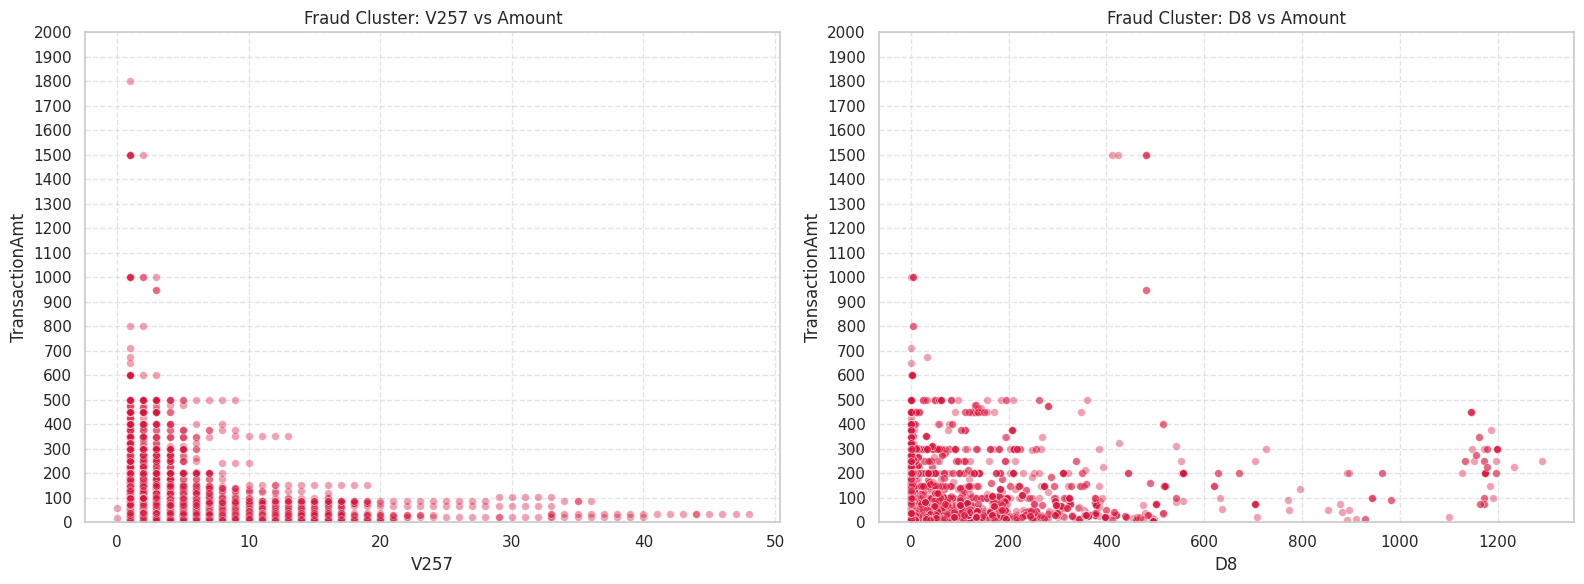

In [41]:
#1-5 (活用)下処理前EDA　不正相関　散布図(amt-V257,amt-D8)

import matplotlib.ticker as ticker

fraud_only = train[train['isFraud'] == 1]
y_limit = 2000
step = 100

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 1. V257 & TransactionAmt
sns.scatterplot(data=fraud_only, x='V257', y='TransactionAmt',
                alpha=0.4, color='crimson', edgecolor='w', s=30, ax=ax[0])
ax[0].set_title('Fraud Cluster: V257 vs Amount')
ax[0].set_ylim(0, y_limit)
# 目盛りの設定
ax[0].yaxis.set_major_locator(ticker.MultipleLocator(step))
ax[0].grid(True, linestyle='--', alpha=0.5)

# 2. D8 & TransactionAmt
sns.scatterplot(data=fraud_only, x='D8', y='TransactionAmt',
                alpha=0.4, color='crimson', edgecolor='w', s=30, ax=ax[1])
ax[1].set_title('Fraud Cluster: D8 vs Amount')
ax[1].set_ylim(0, y_limit)
ax[1].yaxis.set_major_locator(ticker.MultipleLocator(step))
ax[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

不正相関の高いカラムとAmtの散布図を作成したところ以下の特徴が見られた。  
  
①V257  
　・50＄以下ではレンジ0～50で幅広く分布し、以降は金額が高くなるにつれてレンジ及びV値は減少傾向である。例外的にキリのいい金額、上記画像でいえば500,600,1000,1500も捉えやすい。  
　・600＄以上ではレンジ0～5の範囲に収まっているため5区切りでビン追加し、50以降は同じビンとする。
　  

②D8　(欠損87%)  
　・概ね0～400のレンジで多く出現。1100～1200のあたりにも少し固まって出現している。V257同様に高金額帯にいくにつれてレンジ縮小傾向だが300や500のキリのいいところでレンジ拡大しているように見える。  
　・600＄以上では0～50,400～500のレンジで出現している。  
100区切りでビン化が妥当。なお、欠損割合87％である。


上記を踏まえ、Amtについても金額の出現頻度と合わせて特徴量を検討する必要があり。

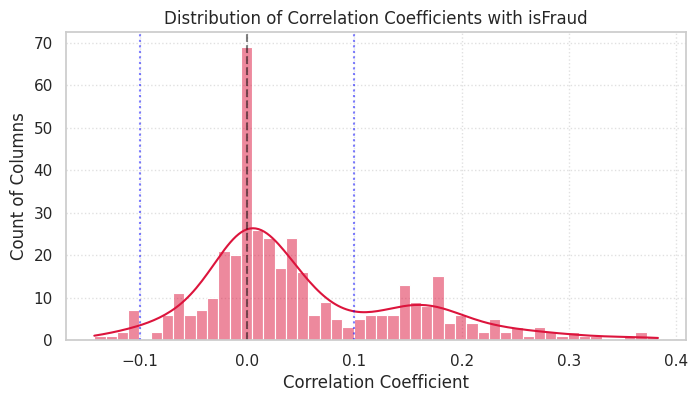

 全数値カラム数: 402 個
 正の相関 (>= 0.1): 108 個
 負の相関 (<= -0.1): 11 個
 低相関 (±0.1未満): 283 個

---  低相関変数リスト ---
TransactionID     0.0142
TransactionDT     0.0131
TransactionAmt    0.0113
card1            -0.0136
card2             0.0034
dtype: float64


In [42]:
#1-6 下処理前EDA　不正相関カラム　ヒストグラム(数値カラムのみ)

# 1. 全数値カラムと不正(isFraud)の相関を計算
numeric_df = train.select_dtypes(include=['number'])
all_corr = numeric_df.corrwith(train['isFraud']).drop('isFraud', errors='ignore')

# 2. 可視化（相関係数のヒストグラム）
plt.figure(figsize=(8, 4))
sns.histplot(all_corr, bins=50, kde=True, color='crimson')
plt.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.axvline(0.1, color='blue', linestyle=':', alpha=0.5)  # しきい値ライン
plt.axvline(-0.1, color='blue', linestyle=':', alpha=0.5)
plt.title('Distribution of Correlation Coefficients with isFraud')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Count of Columns')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# 3. 低相関（±0.1未満）の変数を抽出
low_corr_cols = all_corr[all_corr.abs() < 0.1]

# 4. 統計情報のサマリー表示
print(f"{"="*40}")
print(f" 全数値カラム数: {len(all_corr)} 個")
print(f" 正の相関 (>= 0.1): {(all_corr >= 0.1).sum()} 個")
print(f" 負の相関 (<= -0.1): {(all_corr <= -0.1).sum()} 個")
print(f" 低相関 (±0.1未満): {len(low_corr_cols)} 個")
print(f"{"="*40}")

print("\n---  低相関変数リスト ---")
print(low_corr_cols.head().round(4))

 最大で相関0.38程度であり、特別強い単体の相関は見られなかった。  
 なお、低相関±0.1の範囲において正規分布しており、多くの変数が含まれるものの、相関が低くても変数間の相互作用で寄与する可能性を考慮し、削除は実施せず。

In [43]:
#1-7 下処理前EDA　金額相関(不正と正常値の差)

# 1. データの分離
fraud = train[train['isFraud'] == 1]
normal = train[train['isFraud'] == 0]

# 2. 金額(TransactionAmt)と各数値カラムの相関を計算
corr_fraud = fraud[numeric_col].corrwith(fraud['TransactionAmt'])
corr_normal = normal[numeric_col].corrwith(normal['TransactionAmt'])

# 3. 比較用のDataFrame作成
corr_diff_df = pd.DataFrame({
    'corr_Fraud': corr_fraud,
    'corr_Normal': corr_normal,
    'diff(F-N)': corr_fraud - corr_normal
}).drop('TransactionAmt') # 自分自身の相関(1.0)は除外

# 4. 「差」が激しい（関係性が大きく変わる）TOP10を抽出
# 絶対値でソートして、変化の大きいものをあぶり出す
top_diff = corr_diff_df.reindex(corr_diff_df['diff(F-N)'].abs().sort_values(ascending=False).index).head(10)

print("---  金額との相関ギャップ(昇順) ---")
print(top_diff)

# 1. 差分(Fraudでの相関 - Normalでの相関)を計算し、降順でソート
# ※ここでは「不正の時だけ金額との連動が強くなる」ものを探すため、絶対値ではなく生の差で降順にします
top_5_diff = corr_diff_df.sort_values(by='diff(F-N)', ascending=False).head(5)

---  金額との相関ギャップ(昇順) ---
       corr_Fraud  corr_Normal  diff(F-N)
id_21   -0.359094     0.002974  -0.362068
id_32    0.226341    -0.068329   0.294670
V128     0.314452     0.023771   0.290681
id_07    0.337425     0.072208   0.265217
V306     0.297654     0.034205   0.263449
V126     0.284051     0.026696   0.257355
V50     -0.386354    -0.137185  -0.249170
V127     0.267419     0.020772   0.246646
V202     0.291072     0.055677   0.235395
V164     0.233300    -0.001693   0.234993


id_21、id_32ともに欠損割合85%超　特徴量整理後に全カラム含めて再度確認  
※相関差において、Null値を含むカラムである場合はNull値除くレコードのみで判定されるため注意。(ペアワイズ相関）

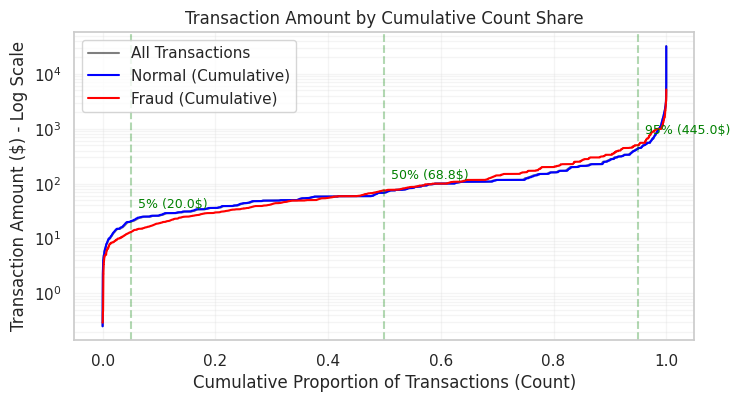

In [44]:
#1-8 (活用)下処理前EDA　累積分布(金額)

# データを金額順にソート
train_sorted = train.sort_values('TransactionAmt').reset_index(drop=True)

# 累計件数の割合（0.0 〜 1.0）を計算
train_sorted['cum_count_pct'] = (train_sorted.index + 1) / len(train_sorted)

plt.figure(figsize=(8, 4))

# 全体の累積件数と金額の推移
plt.plot(train_sorted['cum_count_pct'], train_sorted['TransactionAmt'], label='All Transactions', color='black', alpha=0.5)

# 不正・正常別の累積（それぞれの母数に対する割合）
for label, color, name in zip([0, 1], ['blue', 'red'], ['Normal', 'Fraud']):
    subset = train[train['isFraud'] == label].sort_values('TransactionAmt').reset_index(drop=True)
    cum_pct = (subset.index + 1) / len(subset)
    plt.plot(cum_pct, subset['TransactionAmt'], label=f'{name} (Cumulative)', color=color)

# セグメント検討用のライン（例：下位50%、90%、95%、99%）
for pct in [0.05, 0.5, 0.95]:
    plt.axvline(pct, color='green', linestyle='--', alpha=0.3)
    amt_at_pct = train_sorted.iloc[int(pct * (len(train_sorted)-1))]['TransactionAmt']
    plt.annotate(f'{int(pct*100)}% ({amt_at_pct:.1f}$)', (pct, amt_at_pct), xytext=(5, 10),
                 textcoords='offset points', color='green', fontsize=9)

plt.yscale('log') # 金額の差が激しいため対数スケールが見やすいです
plt.title('Transaction Amount by Cumulative Count Share')
plt.xlabel('Cumulative Proportion of Transactions (Count)')
plt.ylabel('Transaction Amount ($) - Log Scale')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

転換点（X軸：件数割合、Y軸：金額（対数変換））
*   件数割合5％までは傾きの変化が大きく、以降は安定する。また、グラフ幅は縮小傾向
*   件数割合50％以降においても傾きは安定するが、正常値のグラフと不正値のグラフの上下が逆転し、グラフ幅が拡大傾向（不正金額の金額増加量が正常値の金額増加量を上回る）
*   件数割合95％以降は傾きの変化が大きくなり、正常と不正のグラフ幅が縮小していく  

以上より、金額を0～20、20～68.8、68.8～445、445超をビン化して特徴量として追加を行う。  


※なお、前回のポートフォリオ「Credit-Card-Fraud-Analysis
」ではセグメント別にモデル学習を実施していたが、今回はまず特徴量として追加し、モデルに学習させて結果を確認したい。


補足：金額セグメント別について  
　デメリット：不均衡モデルにおいて、少ない不正データをさらに分割するため、特徴量追加のみ行った場合と比較してモデルの学習効率が低下。  
　メリット：閾値調整・重み付けがセグメント別に実施できる。
※高額はリコール優先（件数自体少ないので企業負担が少ない）一方で、低額はプレシジョン優先等。


＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊

上記EDAより、以下の特徴量を追加

1.   金額ビン１（ラウンド数字）　カラム名　'Amt50'  
Amtが50の倍数であれば1、そうでない場合はフラグ0を追加
1.   金額ビン２（2桁目まで99)　　カラム名　'Amt99'  
Amtの1～2桁目が99である場合は1、そうでない場合はフラグ0を追加
1.   金額ビン３（1桁目が9)　　　 カラム名　'Amt9'  
Amtの1桁目が9である場合は1、そうでない場合はフラグ0を追加
1.   金額ビン４（フロートAmt）　 カラム名　'Amt_decimal'  
Amtが小数点以下を含む場合は1、そうでない場合はフラグ0を追加
2.   金額ビン５（レンジ幅）　　　カラム名　'Amt_range'  
Amtが0～599の間は0～50を起点として50区切り、600以降は分けずにビン化。
1.   金額ビン６（累積分布別）　　カラム名　'Amt_turning'   
Amtの0～20、20～68.8、68.8～445、445超をビン化して特徴量として追加を行う。
2.   V257ビン　カラム名('V257bin')  
V257の0～50までは5区切り、51以降は分けずにビン化。  
Null値はそのまま(NaN)。

2.   D8ビン　　カラム名('D8bin')  
D8の0～1200までは100区切り、1201以降は分けずにビン化。  
Null値はそのまま(NaN)。


In [45]:
#1-9 下処理前EDA モデル前 特徴量追加

import numpy as np
import pandas as pd

# 1. 追加・更新したいカラムのリストを定義
new_cols = ['Amt50', 'Amt99', 'Amt9', 'Amt_decimal', 'Amt_range', 'Amt_turning', 'V257bin', 'D8bin']

# 2. 重複防止：既存のカラムがある場合は一度削除
train = train.drop(columns=[c for c in new_cols if c in train.columns])
test = test.drop(columns=[c for c in new_cols if c in test.columns])

# --- ループで train と test 両方に同じ処理を適用 ---
for df in [train, test]:
    # TransactionAmt 関連のフラグ作成
    df['Amt50'] = (df['TransactionAmt'] % 50 == 0).astype('int8')
    df['Amt99'] = (df['TransactionAmt'].fillna(0).astype(int) % 100 == 99).astype('int8')
    df['Amt9'] = (df['TransactionAmt'].fillna(0).astype(int) % 10 == 9).astype('int8')
    df['Amt_decimal'] = (df['TransactionAmt'] % 1 != 0).astype('int8')

    # 累積分布の転換点に基づくビン化 (Amt_turning)
    mask_amt = df['TransactionAmt'].notnull()
    df.loc[mask_amt, 'Amt_turning'] = np.where(df.loc[mask_amt, 'TransactionAmt'] <= 20.0, 0,
                                     np.where(df.loc[mask_amt, 'TransactionAmt'] <= 68.8, 1,
                                     np.where(df.loc[mask_amt, 'TransactionAmt'] <= 445.0, 2, 3)))

    # Amt_range: 50ドル刻み
    df.loc[mask_amt, 'Amt_range'] = np.where(df.loc[mask_amt, 'TransactionAmt'] < 600,
                                            df.loc[mask_amt, 'TransactionAmt'] // 50, 12)

    # V257bin: 50以下の範囲を5刻み
    if 'V257' in df.columns:
        mask_v257 = df['V257'].notnull()
        df.loc[mask_v257, 'V257bin'] = np.where(df.loc[mask_v257, 'V257'] <= 50,
                                               df.loc[mask_v257, 'V257'] // 5, 11)

    # D8bin: 100日刻み
    if 'D8' in df.columns:
        mask_d8 = df['D8'].notnull()
        df.loc[mask_d8, 'D8bin'] = np.where(df.loc[mask_d8, 'D8'] <= 1200,
                                           df.loc[mask_d8, 'D8'] // 100, 13)

    # 3. 型の調整
    for col in new_cols:
        if col in df.columns:
            if df[col].isnull().any():
                df[col] = df[col].astype('float32')
            else:
                df[col] = df[col].astype('int8')

print(f"✅ 特徴量追加完了")
print(f"📊 trainカラム数: {len(train.columns)} / testカラム数: {len(test.columns)}")

✅ 特徴量追加完了
📊 trainカラム数: 442 / testカラム数: 441


In [46]:
#1-10 (参考)下処理前EDA　累積分布(金額)別のシェア

# 1. 日本語の列を綺麗に揃える設定
pd.set_option('display.unicode.east_asian_width', True)
pd.set_option('display.unicode.ambiguous_as_wide', True)

# --- ここから計算処理 ---
# 異常値を排除して集計
clean_df = train[np.isfinite(train['TransactionAmt'])]

summary = clean_df.groupby('Amt_turning').agg({
    'isFraud': ['count', 'mean'],
    'TransactionAmt': ['sum', 'mean']
})

# カラム名のリネーム
summary.columns = ['件数', '不正割合', '合計金額', '平均金額']

# 2. シェアの計算
total_count = summary['件数'].sum()
total_amt_sum = summary['合計金額'].sum()

summary['シェア(件数)'] = (summary['件数'] / total_count) * 100
summary['シェア(金額)'] = (summary['合計金額'] / total_amt_sum) * 100

# 不正割合をパーセント表記に変換
summary['不正割合'] = summary['不正割合'] * 100

# 3. 表示形式の整理
pd.options.display.float_format = '{:.2f}'.format
print("--- Amt_turning 金額セグメント別分析 ---")

# 指定された5つの順番で表示
display_cols = ['件数', 'シェア(件数)', 'シェア(金額)', '平均金額', '不正割合']
print(summary[display_cols])

# 設定をリセット
pd.reset_option('display.float_format')
pd.reset_option('display.unicode.east_asian_width')

--- Amt_turning 金額セグメント別分析 ---
               件数  シェア(件数)  シェア(金額)  平均金額  不正割合
Amt_turning                                                        
0             29864          5.06          0.50     13.48      7.69
1            265413         44.94         14.79     44.44      2.89
2            268259         45.43         53.19    158.11      3.48
3             27004          4.57         31.51    930.47      5.03


金額セグメント別分析  

*   全体の不正割合3.5%と各ビンの割合を比較すると、0ビン(20＄以下)においては7.69％と倍以上の割合であることから集中している価格帯を抽出できている。また、抽出したため1ビン(20～68.8＄)では不正率が全体不正割合を下回る結果となった。  
しかし、2ビン(68.8～445＄)では全体割合とほぼ同率であるが、3ビン(445＄超)においても5.03%と高い結果となった。
*   3ビン(445＄超)において、全体件数の4.57%しかないものの金額のシェアは高く31.51％であり、不正割合も高いことから、ビジネス上ではここの検知率向上、および誤検知の対応が課題となる。


In [47]:
# 2-1 下処理前EDA　寄与度確認１　モデル(lgb)実施

import pandas as pd
import lightgbm as lgb
import gc

# 学習用関数：評価表示を最小限にし、変数を返すことに特化
def run_lgbm_experiment(train_df, target_cols_to_drop=['isFraud', 'TransactionID'], title="LGBM"):
    # 1. データの分離
    X = train_df.drop(target_cols_to_drop, axis=1)
    y = train_df['isFraud']

    # 2. 型の変換
    for col in X.columns:
        if X[col].dtype == 'object':
            X[col] = X[col].astype('category')

    # 3. モデル定義
    ratio = len(y[y==0]) / len(y[y==1])
    model = lgb.LGBMClassifier(
        n_estimators=300,
        random_state=42,
        importance_type='gain',
        scale_pos_weight=ratio,
        n_jobs=-1
    )

    # 4. 学習実行
    print(f"🚀 {title} 開始... ({X.shape[1]} カラム)")
    model.fit(X, y)
    print("✅ 学習完了。")

    # 重要度の算出
    importance_df = pd.DataFrame({
        'feature': X.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    # 後続のセルで NameError にならないよう、すべて返す
    return model, X, y, importance_df

# --- 実行 ---
# ここで model, X, y, importance_df が作成されます
model, X, y, importance_df = run_lgbm_experiment(train, title="初次学習")

🚀 初次学習 開始... (440 カラム)
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 20663, number of negative: 569877
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 3.693238 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 39640
[LightGBM] [Info] Number of data points in the train set: 590540, number of used features: 440
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034990 -> initscore=-3.317076
[LightGBM] [Info] Start training from score -3.317076
✅ 学習完了。


In [48]:
# 2-2 (活用)下処理前EDA　寄与度確認　モデル実行結果

from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import lightgbm as lgb

def report_model_performance(model, X, y, original_df, custom_list=None, title="モデル評価レポート"):
    """
    モデルの基本指標、荷重リコール、混同行列、特徴量重要度を一括表示する関数
    """
    # 1. 予測値の取得
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = model.predict(X)

    # 2. 基本指標の算出
    roc_auc = roc_auc_score(y, y_prob)
    report = classification_report(y, y_pred)
    cm = confusion_matrix(y, y_pred)

    # 3. 荷重リコール (Weighted Recall) の算出
    safe_amt = original_df['TransactionAmt'].astype('float64').fillna(0)
    df_eval = pd.DataFrame({'isFraud': y.values, 'predicted': y_pred, 'amt': safe_amt.values})

    fraud_actual = df_eval[df_eval['isFraud'] == 1]
    total_fraud_amt = fraud_actual['amt'].sum()
    correct_fraud_amt = fraud_actual[fraud_actual['predicted'] == 1]['amt'].sum()
    weighted_recall = correct_fraud_amt / total_fraud_amt if total_fraud_amt > 0 else 0

    # --- 結果の表示 ---
    print(f"\n{'='*10} {title} {'='*10}")
    print(f" ROC-AUC: {roc_auc:.4f}")
    print(f" 荷重リコール (Weighted Recall): {weighted_recall:.4f}")

    print(f"\n--- 詳細レポート ---")
    print(report)

    print(f"\n--- 混同行列 ---")
    print(f"実際＼予測 | 0(正常) | 1(不正)")
    print(f"0(正常)    | {cm[0][0]:7d} | {cm[0][1]:7d}")
    print(f"1(不正)    | {cm[1][0]:7d} | {cm[1][1]:7d}")

    # 4. 特徴量重要度の確認
    importance_df = pd.DataFrame({
        'feature': X.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    if custom_list:
        # 指定されたリストのうち、実際に存在するカラムだけを抽出
        existing_custom = [c for c in custom_list if c in X.columns]
        if existing_custom:
            print(f"\n--- 指定特徴量の戦績 (全{len(X.columns)}カラム中) ---")
            res = importance_df[importance_df['feature'].isin(existing_custom)].copy()
            res['rank'] = res.index + 1
            print(res[['rank', 'feature', 'importance']])

    # 5. 寄与度 0 の確認
    zero_cols = importance_df[importance_df['importance'] == 0]['feature'].tolist()
    print(f"\n 寄与度 0 のカラム数: {len(zero_cols)} / {len(X.columns)}")

    return importance_df, df_eval

# --- ここから実行コマンド ---

# 1. 注目したい自作特徴量のリストを定義
my_features = [
    'Amt50', 'Amt99', 'Amt9', 'Amt_decimal', 'Amt_range',
    'Amt_turning', 'V257bin', 'D8bin',
    'High_Fraud_None', 'High_Fraud_other'
]

# 2. 関数の実行
# 直前の学習セルで作成された model, X, y を使用します
importance_df, eval_df = report_model_performance(
    model=model,
    X=X,
    y=y,
    original_df=train,
    custom_list=my_features,
    title="モデル評価レポート（再学習後）"
)


========== モデル評価レポート（再学習後） ==========
 ROC-AUC: 0.9775
 荷重リコール (Weighted Recall): 0.8899

--- 詳細レポート ---
              precision    recall  f1-score   support

           0       1.00      0.93      0.96    569877
           1       0.33      0.90      0.48     20663

    accuracy                           0.93    590540
   macro avg       0.66      0.92      0.72    590540
weighted avg       0.97      0.93      0.95    590540


--- 混同行列 ---
実際＼予測 | 0(正常) | 1(不正)
0(正常)    |  531772 |   38105
1(不正)    |    2055 |   18608

--- 指定特徴量の戦績 (全440カラム中) ---
     rank      feature    importance
66     67  Amt_decimal  12377.397545
68     69  Amt_turning  11388.299805
173   174        D8bin   1224.977676
181   182    Amt_range   1004.066788
255   256         Amt9    326.563202
259   260        Amt50    308.679001
286   287        Amt99    158.634003
439   440      V257bin      0.000000

 寄与度 0 のカラム数: 109 / 440


現時点でそこそこ良好な結果を得られたが、誤検知数は多い。  
また、追加した特徴量の寄与度ではAmt_decimal,Amt_turningが上位15％に入り、有効であった。  
寄与度のない109件のカラムについては以下で削除。

In [49]:
# 2-3 下処理前EDA　不要カラム削除

import gc

#testデータとtrainデータのカラム表記の揺れを統一、'-'を'_'へ置換
test.columns = [c.replace('-', '_') if 'id' in c else c for c in test.columns]

def prune_low_importance_features(df, importance_df, threshold=0):
    """
    寄与度が一定以下のカラムを削除し、メモリを最適化する
    """
    # 1. 削除対象の特定（重要度 0 以下 かつ df に存在するカラム）
    cols_to_drop = importance_df[importance_df['importance'] <= threshold]['feature'].tolist()

    # ※ 重要な ID や ターゲットを誤って消さないためのガード
    protected_cols = ['isFraud', 'TransactionID']
    # 実際に df に存在し、かつ保護対象でないものだけに絞る
    cols_to_drop = [c for c in cols_to_drop if c in df.columns and c not in protected_cols]

    # 2. カラム削除
    if cols_to_drop:
        df = df.drop(columns=cols_to_drop)
        print(f"✅ 削除完了: 重要度 {threshold} 以下の {len(cols_to_drop)} 個のカラムを削除しました。")
    else:
        print("ℹ️ 削除対象のカラムは見つかりませんでした。")

    # 3. カテゴリカル変数の型再設定
    for col in df.columns:
        if col not in protected_cols and (df[col].dtype == 'object' or df[col].dtype.name == 'category'):
            df[col] = df[col].astype('category')

    # 4. メモリ解放
    gc.collect()

    print(f"📊 現在のデータの形状: {df.shape}")
    return df

# --- 実行コマンド ---

# 1. train から不要カラムを削除
train = prune_low_importance_features(train, importance_df, threshold=0)

# 2. test からも同じカラムを削除して同期
# train のカラム（isFraud以外）で抽出することで、自動的に並び順と構成が一致します
remaining_cols = [c for c in train.columns if c != 'isFraud']
test = test[remaining_cols].copy()

# 3. test の型を train と同期
for col in test.columns:
    if train[col].dtype.name == 'category':
        test[col] = test[col].astype('category')

# 4. 説明変数の再定義
X = train.drop(['isFraud', 'TransactionID'], axis=1)
y = train['isFraud']

# 5. 最終確認
print(f"✅ 同期完了")
print(f"📊 train 形状: {train.shape} / test 形状: {test.shape}")
print(f"🔄 説明変数 X を再定義しました。カラム数: {X.shape[1]}")

gc.collect()

✅ 削除完了: 重要度 0 以下の 109 個のカラムを削除しました。
📊 現在のデータの形状: (590540, 333)
✅ 同期完了
📊 train 形状: (590540, 333) / test 形状: (506691, 332)
🔄 説明変数 X を再定義しました。カラム数: 331


5985

In [50]:
# 2-4 下処理前EDA　寄与度確認２　モデル(lgb)実施(不要カラム削除後)

# 1. 自作特徴量のリスト（ランキング確認用：V257binなど削除済みのものは自動で除外されます）
my_features = [
    'Amt50', 'Amt99', 'Amt9', 'Amt_decimal', 'Amt_range',
    'Amt_turning', 'D8bin',
]

# 2. 関数を呼び出して再学習
# 削除済みの train を使い、内部で X, y の作成・カテゴリ化・学習・評価を完結させます
model_final, X_final, y_final, importance_df_final = run_lgbm_experiment(
    train,
    title="最終学習（不要カラム削除後）"
)

# 3. 評価レポートを表示したい場合はこちら（前回の関数を呼び出し）
# ※report_model_performanceが定義されている必要があります
importance_summary, eval_df = report_model_performance(
    model_final, X_final, y_final, train,
    custom_list=my_features,
    title="精鋭モデル 最終評価"
)

🚀 最終学習（不要カラム削除後） 開始... (331 カラム)
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 20663, number of negative: 569877
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 2.114537 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 36204
[LightGBM] [Info] Number of data points in the train set: 590540, number of used features: 331
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034990 -> initscore=-3.317076
[LightGBM] [Info] Start training from score -3.317076
✅ 学習完了。

========== 精鋭モデル 最終評価 ==========
 ROC-AUC: 0.9775
 荷重リコール (Weighted Recall): 0.8899

--- 詳細レポート ---
              precision    recall  f1-score   support

          

不要カラム削除によって精度は変わらなかったものの、データサイズ削減することに成功。

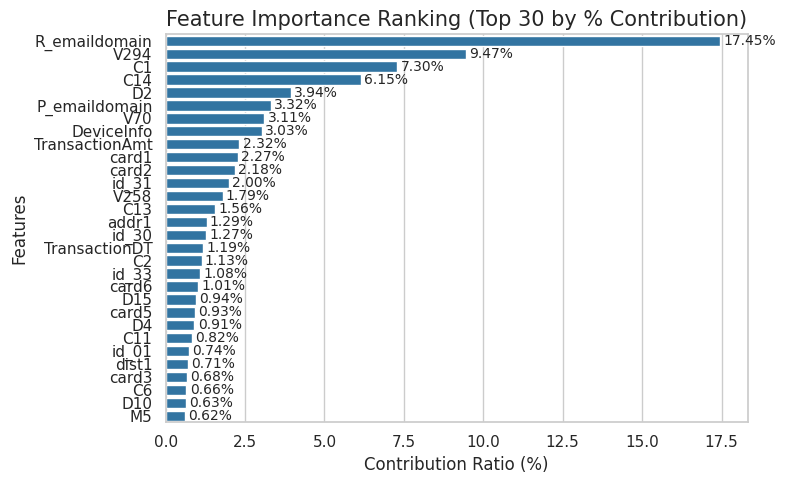

In [51]:
# 2-5 下処理前EDA　寄与度確認

# 1. 重要度の合計を計算し、割合（%）に変換
total_importance = importance_df_final['importance'].sum()
importance_df_final['importance_pct'] = (importance_df_final['importance'] / total_importance) * 100

# 2. 上位30件を抽出
top_30_plot = importance_df_final.head(30).copy()

# 3. グラフの描画
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")

# 自作変数を強調するための色設定（オプション）
custom_features = ['Amt50', 'Amt99', 'Amt9', 'Amt_decimal', 'Amt_range', 'V257bin', 'D8bin']
colors = ['#ff7f0e' if x in custom_features else '#1f77b4' for x in top_30_plot['feature']]

ax = sns.barplot(
    x='importance_pct',
    y='feature',
    data=top_30_plot,
    palette=colors
)

# 数値ラベル（%）を棒の横に表示
for p in ax.patches:
    ax.annotate(f'{p.get_width():.2f}%',
                (p.get_width() + 0.1, p.get_y() + p.get_height()/2), # get_row を get_y に修正
                va='center', fontsize=10)

plt.title('Feature Importance Ranking (Top 30 by % Contribution)', fontsize=15)
plt.xlabel('Contribution Ratio (%)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

グラフ上ではR_emaildomainが1位であるが、寄与度は17.45％であり、強い相関関係のある変数は見られなかった。

In [52]:
# 2-6 下処理前EDA　検知漏れ(擬陰性)データの確認１　統計量

# 1. 見逃した不正(FN)データの抽出
# 直前の学習で作成した 'eval_df' (または 'eval_df_final') を使用します
# 変数名が異なっていた場合は、ここを適切な名前に書き換えてください
target_eval = eval_df

fn_data = target_eval[(target_eval['isFraud'] == 1) & (target_eval['predicted'] == 0)].copy()
fn_details = train.loc[fn_data.index].copy()

# 2. 金額を float64 に変換して inf を回避
fn_amt_safe = fn_details['TransactionAmt'].astype('float64')

print(f"--- 見逃した不正(FN) {len(fn_data):,}件の正確な統計量 ---")

# 統計量の算出
stats = fn_amt_safe.describe()

# フォーマットを整えて表示
print(f"件数:      {stats['count']:,.0f}")
print(f"平均額:    ${stats['mean']:,.2f}")
print(f"標準偏差:  ${stats['std']:,.2f}")
print(f"最小額:    ${stats['min']:,.2f}")
print(f"25%点:     ${stats['25%']:,.2f}")
print(f"中央値:    ${stats['50%']:,.2f}")
print(f"75%点:     ${stats['75%']:,.2f}")
print(f"最大額:    ${stats['max']:,.2f}")

# 全体の不正(isFraud=1)の平均額と比較
total_fraud_amt_mean = train[train['isFraud']==1]['TransactionAmt'].astype('float64').mean()
print(f"\n参考：不正全体の平均額: ${total_fraud_amt_mean:,.2f}")

--- 見逃した不正(FN) 2,055件の正確な統計量 ---
件数:      2,055
平均額:    $165.20
標準偏差:  $299.60
最小額:    $2.23
25%点:     $49.00
中央値:    $87.00
75%点:     $160.00
最大額:    $3,822.00

参考：不正全体の平均額: $149.24


　不正件数の10％程度が検知漏れとなっている。75％点で160＄であり、平均額はこれを上回ることから残りの25％が平均額を牽引している。また、不正全体の平均額は149＄であることから不正全体の中で高額不正の検知漏れが多い可能性が高い。

In [53]:
# 2-7 (参考)下処理前EDA　検知漏れ(擬陰性)データの確認２　金額上位15件

# 1. 見逃した不正(FN)データの抽出
# 直前の学習ステップで返された変数名（eval_df または eval_df_final）に合わせてください
target_eval = eval_df

fn_data = target_eval[(target_eval['isFraud'] == 1) & (target_eval['predicted'] == 0)].copy()
fn_details = train.loc[fn_data.index].copy()

# 2. 金額を float64 に変換
fn_details['TransactionAmt'] = fn_details['TransactionAmt'].astype('float64')

# 3. 調査対象のカラムを絞り込み
target_cols = [
    'TransactionAmt', 'ProductCD', 'TransactionDT', 'addr1', 'dist1',
    'DeviceType', 'DeviceInfo', 'R_emaildomain', 'V294', 'C1',
    'Amt_turning', 'D8bin', 'Amt_range'
]

# 4. 存在するカラムだけを選択（KeyError回避）
available_cols = [col for col in target_cols if col in fn_details.columns]

# 5. 金額順にソートしてトップ15を表示
print(f"--- 検知漏れ高額不正(FN) ワースト15 (全 {len(fn_details):,} 件中) ---")
top_15_fn = fn_details[available_cols].sort_values('TransactionAmt', ascending=False).head(15)
display(top_15_fn)

# 6. 参考：これら15件の合計金額と割合
top_15_sum = top_15_fn['TransactionAmt'].sum()
total_fn_sum = fn_details['TransactionAmt'].sum()

print(f"\nワースト15件の合計被害額: ${top_15_sum:,.2f}")
print(f"検知漏れ総被害額に占める上位15件の割合: {(top_15_sum / total_fn_sum)*100:.2f}%")

--- 検知漏れ高額不正(FN) ワースト15 (全 2,055 件中) ---


,TransactionAmt,ProductCD,TransactionDT,addr1,dist1,DeviceType,DeviceInfo,R_emaildomain,V294,C1,Amt_turning,D8bin,Amt_range
468844,3822.0,W,12085104,204.0,NaN,NaN,NaN,NaN,0.0,1.0,3,NaN,12
226827,3248.0,W,5356445,264.0,5.0,NaN,NaN,NaN,0.0,1.0,3,NaN,12
26694,3082.0,W,678651,299.0,15.0,NaN,NaN,NaN,1.0,1.0,3,NaN,12
504411,3076.0,W,13208033,264.0,NaN,NaN,NaN,NaN,0.0,1.0,3,NaN,12
431094,2964.0,W,10885899,251.0,24.0,NaN,NaN,NaN,0.0,2.0,3,NaN,12
400086,2878.0,W,10093070,177.0,NaN,NaN,NaN,NaN,0.0,1.0,3,NaN,12
378443,2700.0,W,9477048,299.0,NaN,NaN,NaN,NaN,0.0,1.0,3,NaN,12
26554,2594.0,W,676570,299.0,15.0,NaN,NaN,NaN,0.0,1.0,3,NaN,12
584743,2480.0,W,15631810,327.0,NaN,NaN,NaN,NaN,0.0,1.0,3,NaN,12
362226,2396.0,W,8980892,158.0,NaN,NaN,NaN,NaN,0.0,1.0,3,NaN,12



ワースト15件の合計被害額: $39,918.00
検知漏れ総被害額に占める上位15件の割合: 11.76%


高額検知漏れ(TOP15)共通項

*   ProductCDは全て「Ｗ」
*   全てNaN(DeviceType,DeviceInfo,R_emaildomain,D8bin)
*   Amt_decimalは全て0
*   Amt_range	は全て12(600＄以上)
*   Amt_turning3(445＄超)   
※高額不正キャッチアップの特徴量追加する場合はrangeとturningどちらを有効とするか、両方作るか要検討。
*   要分布確認(addr1)　177～322
*   要分布確認(V294)　0～1、14/15件が0
*   要分布確認(C1)　1～2、14/15件が1










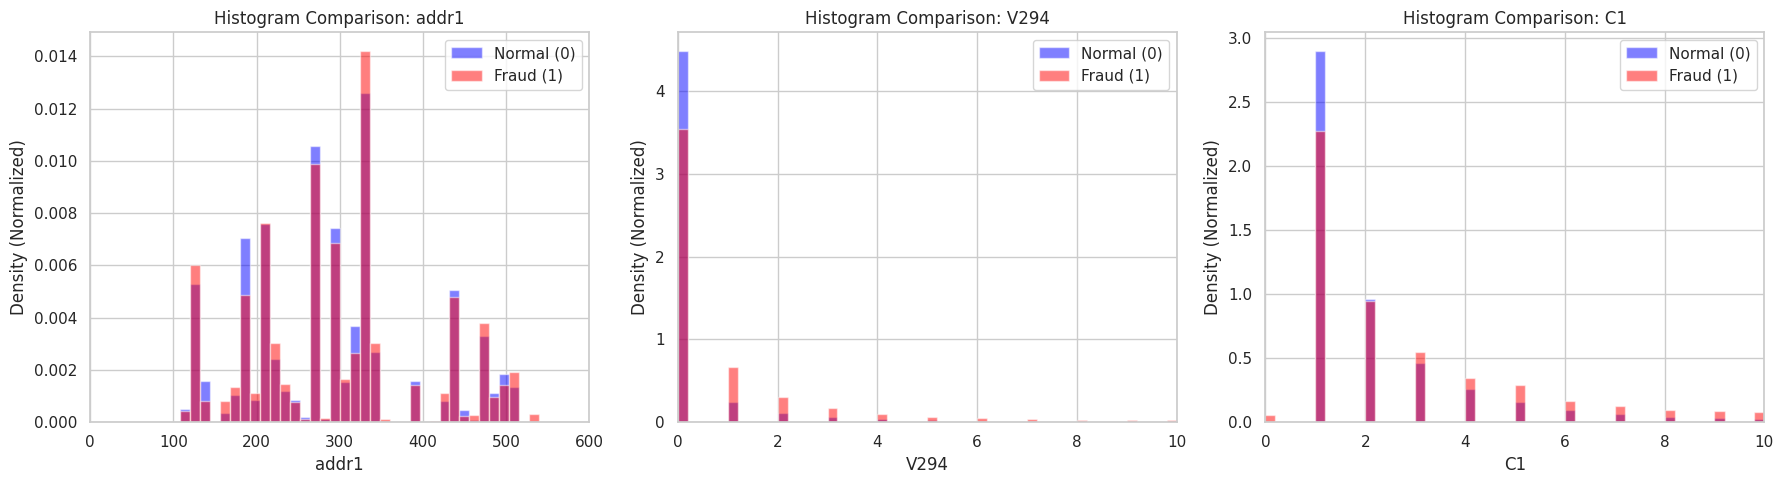

In [54]:
# 2-8 (参考)下処理前EDA　検知漏れ(擬陰性)データの確認２　金額上位15件

import matplotlib.pyplot as plt
import seaborn as sns

# 比較したいカラムと、それぞれの表示範囲（x軸の最大値）を設定
# データの分布に合わせて調整してください
check_settings = {
    'addr1': (0, 600),
    'V294': (0, 10),   # 1200まであるが、実態は10以下に集中
    'C1': (0, 10)     # 5000まであるが、実態は30以下に集中
}

plt.figure(figsize=(18, 5))

for i, (col, x_range) in enumerate(check_settings.items()):
    plt.subplot(1, 3, i+1)

    # 正常（isFraud=0）: 棒グラフ
    plt.hist(train[train['isFraud'] == 0][col].dropna(),
             bins=50, range=x_range, alpha=0.5, label='Normal (0)', color='blue', density=True)

    # 不正（isFraud=1）: 棒グラフ
    plt.hist(train[train['isFraud'] == 1][col].dropna(),
             bins=50, range=x_range, alpha=0.5, label='Fraud (1)', color='red', density=True)

    plt.title(f'Histogram Comparison: {col}')
    plt.xlabel(col)
    plt.ylabel('Density (Normalized)')
    plt.xlim(x_range)
    plt.legend()

plt.tight_layout()
plt.show()

分布確認(addr1,V294	,C1)  
　V294及びC1は寄与度上位２位及び３位の指標であるが、高額不正ではいずれも正常値と重なっており、現時点のモデルではキャッチアップが困難である。  
　打開策としては以下の２点が考えられる。
1.   セグメント別モデル(累積分布上位5%)
2.   特徴量追加(高額不正指標)  
検知漏れ金額上位50まで確認したところ、addr1はばらつきが大きいためスコアリングに含むのは困難であるため除外。  

まずは２について以下で実施を行う。
  
  ※補足：高額検知漏れの上位50件にC1が0のものはなかったがヒストグラムでは0の位置に不正のみがあった。LightGBMでは当該事項についてキャッチアップしてると判断し、フラグ追加は実施しない。
  





In [55]:
#2-9　下処理前EDA　検知漏れ(擬陰性)データの確認３

# 1. 高額な検知漏れ（Amt_turning >= 3）をベースにする
fn_high = fn_details[fn_details['Amt_turning'] >= 3].copy()
total_high_fn = len(fn_high)

# 2. 各カラムの条件合致数をカウント
analysis_results = []

# 条件リストの定義
conditions = [
    ('ProductCD == "W"', fn_high['ProductCD'] == 'W'),
    ('DeviceType is None', fn_high['DeviceType'].isna()),
    ('DeviceInfo is None', fn_high['DeviceInfo'].isna()),
    ('R_emaildomain is None', fn_high['R_emaildomain'].isna()),
    ('Amt_decimal is 0', fn_high['TransactionAmt'] % 1 == 0),
    ('V294 is 0-1', fn_high['V294'] <= 1),
    ('C1 is 1-2', fn_high['C1'].between(1, 2))
]

for label, cond in conditions:
    count = cond.sum()
    ratio = (count / total_high_fn) * 100
    analysis_results.append({'条件': label, '件数': count, '割合(%)': round(ratio, 2)})

# 結果の表示
import pandas as pd
res_df = pd.DataFrame(analysis_results)
print(f"--- 高額検知漏れ（$445超） 全{total_high_fn}件の内訳 ---")
display(res_df)

--- 高額検知漏れ（$445超） 全123件の内訳 ---


,条件,件数,割合(%)
0,"ProductCD == ""W""",121,98.37
1,DeviceType is None,122,99.19
2,DeviceInfo is None,122,99.19
3,R_emaildomain is None,121,98.37
4,Amt_decimal is 0,111,90.24
5,V294 is 0-1,123,100.00
6,C1 is 1-2,115,93.50


いずれも高額不正との相関が高い結果となったが、100％は１つだけであった。特徴量を追加する場合は要調整。

In [56]:
'''
特徴量追加(高額不正指標)  カラム名'High_Fraud'

①フラグ　カラム名'High_Fraud_None'
Amt_turning3(445＄超)以上
かつ
リスト１に３つ以上該当すれば1、その他0

②フラグ　カラム名'High_Fraud_other'
Amt_turning3(445＄超)以上
かつ
リスト１に２つ以上該当すれば1、それ以外0

----リスト1(98%超)----
ProductCDが「Ｗ」
None(DeviceType)
None(DeviceInfo)
None(R_emaildomain)

----リスト2(90%超)----
Amt_decimalが0
V294が0～1以内
C1が1～2以内


'''

"\n特徴量追加(高額不正指標)  カラム名'High_Fraud'\n\n①フラグ\u3000カラム名'High_Fraud_None'\nAmt_turning3(445＄超)以上\nかつ\nリスト１に３つ以上該当すれば1、その他0\n\n②フラグ\u3000カラム名'High_Fraud_other'\nAmt_turning3(445＄超)以上\nかつ\nリスト１に２つ以上該当すれば1、それ以外0\n\n----リスト1(98%超)----\nProductCDが「Ｗ」\nNone(DeviceType)\nNone(DeviceInfo)\nNone(R_emaildomain)\n\n----リスト2(90%超)----\nAmt_decimalが0\nV294が0～1以内\nC1が1～2以内\n\n\n"

In [57]:
#3-1 下処理前EDA  特徴量追加(高額不正指標)

# --- 実行コマンド ---

for df in [train, test]:
    # 1. 判定用の補助スコア計算（各行ごとに条件合致数を合計）

    # リスト1の条件（情報の欠落系）
    l1_score = (
        (df['ProductCD'] == 'W').astype(int) +
        (df['DeviceType'].isna()).astype(int) +
        (df['DeviceInfo'].isna()).astype(int) +
        (df['R_emaildomain'].isna()).astype(int)
    )

    # リスト2の条件（擬態・整数系）
    l2_score = (
        (df['TransactionAmt'] % 1 == 0).astype(int) +
        (df['V294'].fillna(0) <= 1).astype(int) + # Nullは0扱い
        (df['C1'].between(1, 2)).astype(int)
    )

    # 2. フラグ作成
    # ① High_Fraud_None: 高額(Amt_turning >= 3) かつ リスト1に3つ以上該当
    df['High_Fraud_None'] = ((df['Amt_turning'] >= 3) & (l1_score >= 3)).astype('int8')

    # ② High_Fraud_other: 高額(Amt_turning >= 3) かつ リスト2に2つ以上該当
    df['High_Fraud_other'] = ((df['Amt_turning'] >= 3) & (l2_score >= 2)).astype('int8')

print(f"✅ 高額不正指標の追加完了")
print(f"📊 train: None={train['High_Fraud_None'].sum()}, Other={train['High_Fraud_other'].sum()}")
print(f"📊 test : None={test['High_Fraud_None'].sum()}, Other={test['High_Fraud_other'].sum()}")

✅ 高額不正指標の追加完了
📊 train: None=24916, Other=26394
📊 test : None=20030, Other=22168


参考：不正件数　20,663件

In [58]:
#3-2　下処理前EDA　特徴量追加(高額不正指標)　モデル実行評価

# 1. 注目したい自作変数のリスト（新しく作った High_Fraud を追加）
my_features = [
    'Amt_turning', 'Amt_decimal', 'D8bin', 'Amt_range',
    'High_Fraud_None', 'High_Fraud_other'
]

# 2. 関数を呼び出して学習（High_Fraud 込みの train を使用）
# ※ run_lgbm_experiment 内で自動的に X, y が作り直されます
model_new, X_new, y_new, importance_df_new = run_lgbm_experiment(
    train,
    title="LGBM: 新特徴量(High_Fraud)導入後"
)

# 3. 評価レポートの表示
# これにより、High_Fraud_None/other が重要度何位にランクインしたか分かります
importance_summary, eval_df_new = report_model_performance(
    model_new, X_new, y_new, train,
    custom_list=my_features,
    title="新特徴量導入後の最終スコア"
)

# 4. 前回のモデル（eval_df）と今回のモデル（eval_df_new）で FN の数を比較
old_fn = len(eval_df[(eval_df['isFraud'] == 1) & (eval_df['predicted'] == 0)])
new_fn = len(eval_df_new[(eval_df_new['isFraud'] == 1) & (eval_df_new['predicted'] == 0)])

print(f"\n--- 改善結果の比較 ---")
print(f"見逃した不正(FN)の数: {old_fn}件 -> {new_fn}件 (差分: {new_fn - old_fn}件)")

🚀 LGBM: 新特徴量(High_Fraud)導入後 開始... (333 カラム)
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 20663, number of negative: 569877
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.760136 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 36208
[LightGBM] [Info] Number of data points in the train set: 590540, number of used features: 333
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034990 -> initscore=-3.317076
[LightGBM] [Info] Start training from score -3.317076
✅ 学習完了。

========== 新特徴量導入後の最終スコア ==========
 ROC-AUC: 0.9776
 荷重リコール (Weighted Recall): 0.8898

--- 詳細レポート ---
              precision    recall  f1-score   suppo

　特徴量追加を試みたが効果がなかった。モデルは既にこのパターンを学習済みであり、問題は正常取引との分離が困難な点にある。モデル実行時においてはセグメント別に実施を検討。

下処理前EDA結果  

　Amt_decimalとAmt_turningが有効な特徴量であることを確認。高額帯の検知漏れは特徴量追加では解決困難であり、モデリング時にセグメント別実施を検討。次ファイルではカテゴリ変数の変換と外れ値処理を行う。  
    

反省点(下処理前EDA及びデータクレンジング)
*   下処理前EDAでやるべき範囲を整理しきれてなかったため、冗長な進め方となったこと。  
ただ、その反面、高額不正について深堀りすることでモデル実行時の方向性が固まったが、後続の特徴量変換によって変わる可能性も充分にある。そのため、今回のファイルではLightGBMでカラム削減後の寄与度確認で止め、特徴量変換後の試走で深堀りすべき事項ではあったと思料される。  
この点については、今回の課題のみで断定せず、経験を積む中で効率的な処理の仕方を洗練させていきたい。

*   テストデータと学習データの整合性  
　モデル試走後のKeyerrorで表記の揺れ(「」-と「_」)が発覚したが、前ファイルのデータクレンジングで実施しておくべきことであった。  



*   データ型の変換  
オブジェクト型、ストリング型は今回なかったが、前回のデータクレンジングの初期の段階でカテゴリー型に変換しておくべきであった。





In [59]:
'''
後続処理
済①下処理前EDA
　　なお、長くなったため、見出しに特徴量等を変化させたものは(活用)、
　　変化はないが有効な情報に(参考)を付与した。
②欠損処理の検討
　以下の２点により省略。
　LightGBMでは欠損値について、欠損値として学習できること。
　現時点である程度の精度は確保できており、欠損値補完により精度が落ちるリスクがあること。
③特徴量変換(ビン分け、外れ値処理、ラベル化の検討)
　金額については当該ファイルにて確認済みのため、外れ値のみ検討を実施。
　主にストリング型、オブジェクト型について検討を行う。
④下処理後EDA
　ストリング型の加工後にモデル評価したのちに重要度が高いものがあれば実施。
'''

'\n後続処理\n済①下処理前EDA\n\u3000\u3000なお、長くなったため、見出しに特徴量等を変化させたものは(活用)、\n\u3000\u3000変化はないが有効な情報に(参考)を付与した。\n②欠損処理の検討\n\u3000以下の２点により省略。\n\u3000LightGBMでは欠損値について、欠損値として学習できること。\n\u3000現時点である程度の精度は確保できており、欠損値補完により精度が落ちるリスクがあること。\n③特徴量変換(ビン分け、外れ値処理、ラベル化の検討)\n\u3000金額については当該ファイルにて確認済みのため、外れ値のみ検討を実施。\n\u3000主にストリング型、オブジェクト型について検討を行う。\n④下処理後EDA\n\u3000ストリング型の加工後にモデル評価したのちに重要度が高いものがあれば実施。\n'

In [61]:
import os

# 1. 保存ファイル名の設定
train_path = 'train_EDA1.parquet'
test_path = 'test_EDA1.parquet'

# 2. Parquet形式で出力
train.to_parquet(train_path, index=False)
test.to_parquet(test_path, index=False)

print(f"✅ 保存完了!")
print(f"📊 Train形状: {train.shape} -> {train_path}")
print(f"📊 Test 形状: {test.shape} -> {test_path}")

# 3. ファイルサイズの確認
for path in [train_path, test_path]:
    file_size = os.path.getsize(path) / (1024 * 1024)
    print(f"📁 {path} サイズ: {file_size:.2f} MB")

✅ 保存完了!
📊 Train形状: (590540, 335) -> train_EDA1.parquet
📊 Test 形状: (506691, 334) -> test_EDA1.parquet
📁 train_EDA1.parquet サイズ: 67.01 MB
📁 test_EDA1.parquet サイズ: 58.67 MB
